In [1]:
# Import packages

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### INPUT USER: update paths

data_path = "/Users/laureleblanc/Desktop/Collective-twitching-2026/2_collective_organization/nematic_correlation_decay_length/dataset/"
figures_dir = "/Users/laureleblanc/Desktop/Collective-twitching-2026/2_collective_organization/nematic_correlation_decay_length/figures/"

In [3]:
def extract_surface_coverage(filename):
    if "SC10pc" in filename:
        return 10
    elif "SC30pc" in filename:
        return 30
    elif "SC70pc" in filename:
        return 70
    else:
        return None  

def extract_strain(filename):
    strains = ['177', '232', '459', '337', '436']
    for strain in strains:
        if strain in filename:
            return strain
    return None 

def replace_legend_label(label):
    strain_labels = {
        '177': 'WT',
        '232': r'$\Delta\mathit{pilH}$',
        '459': r'$\Delta\mathit{pilG}$',
        '337' : r'$\Delta\mathit{cpdA}$',
        '436' : r'$\Delta\mathit{pilH\ cyaB}$'
    }
    return strain_labels.get(label, label)


# Decay length

/var/folders/6n/9gbq90b95yggb0kc46nkmg8c0000gn/T/ipykernel_73591/669971152.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = strain_data.groupby('SC_bin')['b'].mean()


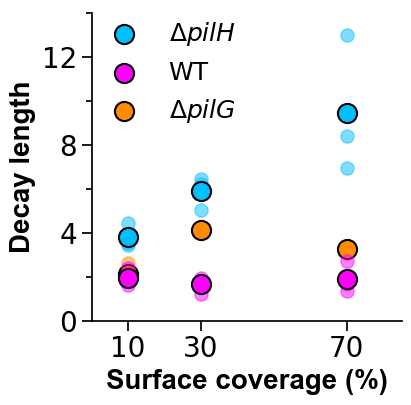

In [4]:
### Figure 1.G
### Normalized decay length = decay length / mean bacterial width.
# In the following, b refers to the decay length (in µm)

# Mean width
mean_width = 0.8  # microns

# Open combined CSV
df = pd.read_csv(data_path + '/fitting_results_combined.csv', sep=';')
df['SC'] = df['Filename'].apply(extract_surface_coverage)
df['Strain'] = df['Filename'].apply(extract_strain)

# Normalize decay length b by mean width
df['b'] = df['b'] / mean_width

# Define bins and labels for surface coverage
bins = [0, 15, 40, 75]
bin_labels = [10, 30, 70]
df['SC_bin'] = pd.cut(df['SC'], bins=bins, labels=bin_labels)

# Assign colormap
color_map = {'177': 'magenta', '232': 'deepskyblue', '459': 'darkorange', '337':'darksalmon', '436': 'mediumblue'}

plt.figure(figsize=(4, 4))

for strain in ['232', '177', '459']:
    strain_data = df[df['Strain'] == strain]
    
    # WT strain '177' gets a higher zorder
    z = 3 if strain == '177' else 2
    
    # Plot individual points (already normalized)
    plt.scatter(strain_data['SC'], strain_data['b'], s=90,
                color=color_map[strain], alpha=0.5, zorder=z)
    
    # Plot means per SC bin (already normalized)
    grouped = strain_data.groupby('SC_bin')['b'].mean()
    legend_label = replace_legend_label(strain)
    
    plt.scatter(bin_labels, grouped.values, color=color_map[strain], s=190, alpha=1,
                edgecolors='black', linewidths=1.5, label=legend_label, zorder=z)

# Average b values for 1047 and 1695 (already normalized)
avg_b_1047 = df[df['Strain'] == '1047']['b'].mean()
avg_b_1695 = df[df['Strain'] == '1695']['b'].mean()

# Horizontal shaded region
#lower = min(avg_b_1047, avg_b_1695)
#upper = max(avg_b_1047, avg_b_1695)
#plt.axhspan(lower, upper, color='lightgray', alpha=0.5, zorder=0)

# Formatting
plt.legend(loc='upper left', fontsize=18, frameon = False, bbox_to_anchor = (-0.05, 1.05))
plt.xlabel('Surface coverage (%)', fontsize=20, fontweight='bold', fontname='Arial')
plt.ylabel(r'Decay length', fontsize=20, fontweight='bold', fontname='Arial')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.xticks(ticks=[10, 30, 70])
plt.yticks(ticks=[0, 4, 8, 12])
plt.xlim([0, 85])
plt.ylim([0, 14])
plt.gca().spines['top'].set_linewidth(False)
plt.gca().spines['right'].set_linewidth(False)
plt.gca().spines['left'].set_linewidth(1.25)
plt.gca().spines['bottom'].set_linewidth(1.25)
plt.gca().yaxis.set_minor_locator(plt.FixedLocator([0, 2, 6, 10, 14]))
plt.gca().tick_params(axis='both', which='major', length=7, width=1.25, color='black')
plt.gca().tick_params(axis='both', which='minor', length=4, width=1.25, color='black')

# Save the figure
plt.savefig(figures_dir + 'decay-length_Figure1.png', dpi=300, bbox_inches='tight', transparent = True)
plt.show()


/var/folders/6n/9gbq90b95yggb0kc46nkmg8c0000gn/T/ipykernel_73591/4197567670.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = strain_data.groupby('SC_bin')['b'].mean()


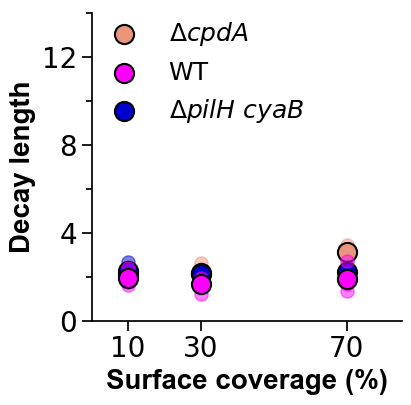

In [5]:
### Figure 2.E

# Mean width
mean_width = 0.8  # microns

# Open combined CSV
df = pd.read_csv(data_path + '/fitting_results_combined.csv', sep=';')
df['SC'] = df['Filename'].apply(extract_surface_coverage)
df['Strain'] = df['Filename'].apply(extract_strain)

# Normalize decay length b by mean width
df['b'] = df['b'] / mean_width

# Define bins and labels for surface coverage
bins = [0, 15, 40, 75]
bin_labels = [10, 30, 70]
df['SC_bin'] = pd.cut(df['SC'], bins=bins, labels=bin_labels)

# Assign colormap
color_map = {'177': 'magenta', '232': 'deepskyblue', '459': 'darkorange', '337':'darksalmon', '436': 'mediumblue'}

plt.figure(figsize=(4, 4))

for strain in ['337', '177', '436']:
    strain_data = df[df['Strain'] == strain]
    
    # WT strain '177' gets a higher zorder
    z = 3 if strain == '177' else 2
    
    # Plot individual points (already normalized)
    plt.scatter(strain_data['SC'], strain_data['b'], s=90,
                color=color_map[strain], alpha=0.5, zorder=z)
    
    # Plot means per SC bin (already normalized)
    grouped = strain_data.groupby('SC_bin')['b'].mean()
    legend_label = replace_legend_label(strain)
    
    plt.scatter(bin_labels, grouped.values, color=color_map[strain], s=190, alpha=1,
                edgecolors='black', linewidths=1.5, label=legend_label, zorder=z)

# Average b values for 1047 and 1695 (already normalized)
avg_b_1047 = df[df['Strain'] == '1047']['b'].mean()
avg_b_1695 = df[df['Strain'] == '1695']['b'].mean()

# Horizontal shaded region
#lower = min(avg_b_1047, avg_b_1695)
#upper = max(avg_b_1047, avg_b_1695)
#plt.axhspan(lower, upper, color='lightgray', alpha=0.5, zorder=0)

# Formatting
plt.legend(loc='upper left', fontsize=18, frameon = False, bbox_to_anchor = (-0.05, 1.05))
plt.xlabel('Surface coverage (%)', fontsize=20, fontweight='bold', fontname='Arial')
plt.ylabel(r'Decay length', fontsize=20, fontweight='bold', fontname='Arial')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.xticks(ticks=[10, 30, 70])
plt.yticks(ticks=[0, 4, 8, 12])
plt.xlim([0, 85])
plt.ylim([0, 14])
plt.gca().spines['top'].set_linewidth(False)
plt.gca().spines['right'].set_linewidth(False)
plt.gca().spines['left'].set_linewidth(1.25)
plt.gca().spines['bottom'].set_linewidth(1.25)
plt.gca().yaxis.set_minor_locator(plt.FixedLocator([0, 2, 6, 10, 14]))
plt.gca().tick_params(axis='both', which='major', length=7, width=1.25, color='black')
plt.gca().tick_params(axis='both', which='minor', length=4, width=1.25, color='black')

# Save the figure
plt.savefig(figures_dir + 'decay-length_Figure2.png', dpi=300, bbox_inches='tight', transparent = True)
plt.show()
